# 0장 · PennyLane을 위한 수학적 기초 — 실습 노트북

이 노트북은 이론 노트 **「0장. PennyLane을 위한 수학적 기초」**의 7개 절을 코드로 직접 확인하는 핸즈온 자료다.
모든 수학 개념을 **NumPy로 손으로 검증**한 뒤, 학습·미분·표현력처럼 양자 머신러닝의 핵심이 되는 부분은 **PennyLane**으로 이어서 다룬다.

각 셀은 `직관 → 수식 → 코드` 순서로 배치했고, 코드에는 줄 단위 주석과 함께 출력 해석을 덧붙였다.

> **실행 준비** — 아래 라이브러리가 필요하다. 설치돼 있지 않다면 주석을 풀고 한 번 실행하면 된다.
>
PennyLane은 `pip install pennylane`으로 설치할 수 있다. 본 튜토리얼에서는 시뮬레이터 `default.qubit`만 사용하므로 추가 플러그인은 필요 없다.

In [ ]:
%pip install pennylane numpy scipy matplotlib

In [1]:
# !pip install pennylane numpy scipy matplotlib
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

# 출력 자릿수를 줄여 행렬을 보기 좋게 만든다
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__)

NumPy 2.2.6


## 0.1 복소수와 복소 벡터공간 — 양자 진폭의 언어

양자 상태는 **복소 진폭(amplitude)**으로 기술되고, 측정 확률은 그 진폭의 **절댓값 제곱**으로 주어진다.
복소수가 필요한 이유는 위상(phase)이 담는 **간섭** 정보를 실수만으로는 표현할 수 없기 때문이다.

In [3]:
# 파이썬은 허수 단위를 j로 표기한다 (i가 아니라 j)
z = 2 + 3j

print("z          =", z)
print("실수부 Re(z) =", z.real)
print("허수부 Im(z) =", z.imag)
print("켤레 conj(z) =", z.conjugate())   # a+bi -> a-bi
print("크기 |z|     =", abs(z))           # sqrt(a^2+b^2)

# z·conj(z) = |z|^2 (측정 확률의 핵심)
print("|z|^2        =", (z * z.conjugate()).real)  

z          = (2+3j)
실수부 Re(z) = 2.0
허수부 Im(z) = 3.0
켤레 conj(z) = (2-3j)
크기 |z|     = 3.605551275463989
|z|^2        = 13.0


**코드 설명** — `z.conjugate()`는 켤레 z̄를, `abs(z)`는 크기 |z|를 준다. 특히 `z·z̄ = |z|²`가 실수로 떨어지는데, 이 값이 곧 측정 확률로 연결되는 양이다.

다음으로 **오일러 공식** `e^{iθ} = cosθ + i·sinθ`를 수치로 확인한다.

In [4]:
theta = np.pi / 3                       # 60도

lhs = np.exp(1j * theta)                # 복소 지수 e^{iθ}
rhs = np.cos(theta) + 1j*np.sin(theta)  # cosθ + i·sinθ

print("e^{iθ}        =", lhs)
print("cosθ + i·sinθ =", rhs)
print("두 값이 같은가? ->", np.allclose(lhs, rhs))   # 부동소수 비교는 allclose로

e^{iθ}        = (0.5000000000000001+0.8660254037844386j)
cosθ + i·sinθ = (0.5000000000000001+0.8660254037844386j)
두 값이 같은가? -> True


**코드 설명** — `np.exp(1j*theta)`가 단위원 위의 한 점을 가리키며, `cosθ + i·sinθ`와 정확히 일치한다. 즉 복소 위상은 회전 각도와 같다.

이제 큐비트 상태를 **정규화된 2차원 복소 벡터**로 만들고, Born 규칙으로 측정 확률을 읽는다.

In [5]:
# |ψ> = α|0> + β|1>,  α,β ∈ ℂ
alpha = 1/np.sqrt(2)
beta  = 1j/np.sqrt(2)
psi = np.array([alpha, beta])

print("ψ =", psi)
print("정규화 |α|²+|β|² =", np.sum(np.abs(psi)**2))  # 반드시 1
print("P(측정=0) = |α|² =", np.abs(alpha)**2)
print("P(측정=1) = |β|² =", np.abs(beta)**2)

ψ = [0.7071+0.j     0.    +0.7071j]
정규화 |α|²+|β|² = 0.9999999999999998
P(측정=0) = |α|² = 0.4999999999999999
P(측정=1) = |β|² = 0.4999999999999999


**코드 설명** — `np.abs(psi)**2`이 각 진폭의 |·|²을 한 번에 계산한다. 합이 1이라는 것은 "모든 측정 확률의 합 = 1"이라는 정규화 조건과 같은 의미다.

## 0.2 디랙 표기법과 힐베르트 공간 — 켓·브라·내적

켓 `|ψ>`은 복소 **열벡터**, 브라 `<ψ|`은 그 **켤레전치**다. 내적 `<φ|ψ>`은 두 상태가 얼마나 겹치는지를 재는 복소수이며, 자기 자신과의 내적의 제곱근이 **노름**이다.

In [6]:
# 계산 기저
ket0 = np.array([1, 0], dtype=complex)   # |0>
ket1 = np.array([0, 1], dtype=complex)   # |1>

psi = (ket0 + 1j*ket1) / np.sqrt(2)      # |ψ> = (|0> + i|1>)/√2
phi = (ket0 +     ket1) / np.sqrt(2)     # |φ> = (|0> + |1>)/√2

# 내적 <φ|ψ> : numpy vdot은 첫 인자를 자동으로 켤레해 준다
print("<φ|ψ> =", np.vdot(phi, psi))
print("노름 ||ψ|| =", np.sqrt(np.vdot(psi, psi).real))

<φ|ψ> = (0.4999999999999999+0.4999999999999999j)
노름 ||ψ|| = 0.9999999999999999


**코드 설명** — `np.vdot(phi, psi)`는 `Σ conj(φ_k)·ψ_k`를 계산하므로 브라-켓 내적과 정확히 같다. 노름이 1이면 적법한 양자 상태다.

정규직교 기저는 `<i|j> = δ_ij`를, 외적 `|ψ><ψ|`은 **사영 연산자**를 만든다.

In [7]:
# 정규직교성: 같은 기저끼리는 1, 다른 기저끼리는 0
print("<0|0> =", np.vdot(ket0, ket0).real)
print("<0|1> =", np.vdot(ket0, ket1).real)

# 외적 |0><0| = 사영 연산자
P0 = np.outer(ket0, ket0.conj())
print("\n사영 연산자 |0><0| =\n", P0.real)
print("멱등성 P² = P ? ->", np.allclose(P0 @ P0, P0))

# 완전성 관계: Σ_k |k><k| = I
completeness = np.outer(ket0, ket0.conj()) + np.outer(ket1, ket1.conj())
print("완전성 Σ|k><k| = I ? ->", np.allclose(completeness, np.eye(2)))

<0|0> = 1.0
<0|1> = 0.0

사영 연산자 |0><0| =
 [[1. 0.]
 [0. 0.]]
멱등성 P² = P ? -> True
완전성 Σ|k><k| = I ? -> True


**코드 설명** — `np.outer(a, b.conj())`가 외적 `|a><b|`을 행렬로 만든다. `|0><0|`은 멱등(P²=P)이라 사영 연산자의 정의를 만족하고, 두 사영의 합이 항등행렬이 되는 것이 완전성 관계다.

## 0.3 선형 연산자와 유니터리 — 양자 게이트의 수학

양자 게이트는 **유니터리(U†U = I)** 연산자다. 가장 기본인 **Pauli 행렬**은 Hermitian인 동시에 유니터리이며, 회전 게이트의 생성원이 된다.

In [8]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1],[1, 0]],   dtype=complex)
Y = np.array([[0,-1j],[1j, 0]], dtype=complex)
Z = np.array([[1, 0],[0,-1]],   dtype=complex)

for name, A in [("X", X), ("Y", Y), ("Z", Z)]:
    is_herm = np.allclose(A, A.conj().T)        # A == A†
    is_unit = np.allclose(A.conj().T @ A, I)    # A†A == I
    print(f"{name}:  Hermitian={is_herm},  Unitary={is_unit}")

X:  Hermitian=True,  Unitary=True
Y:  Hermitian=True,  Unitary=True
Z:  Hermitian=True,  Unitary=True


**코드 설명** — `A.conj().T`가 수반 A†(켤레전치)다. Pauli 행렬은 두 성질을 동시에 만족하는 특별한 연산자다.

회전 게이트 `R_g(θ) = e^{-iθg/2}`는 행렬 지수로 정의된다. `scipy.linalg.expm`으로 계산해 닫힌 형태와 비교한다.

In [9]:
def R(g, theta):
    """생성원 g(=X,Y,Z 등)에 대한 회전 게이트 e^{-iθg/2}"""
    return expm(-1j * theta/2 * g)

theta = np.pi/2
RX = R(X, theta)

# 닫힌 형태: cos(θ/2)·I - i·sin(θ/2)·g
closed = np.cos(theta/2)*I - 1j*np.sin(theta/2)*X

print("expm(-iθX/2) =\n", RX)
print("\n닫힌 형태와 일치? ->", np.allclose(RX, closed))
print("유니터리? ->", np.allclose(RX.conj().T @ RX, I))

expm(-iθX/2) =
 [[0.7071+0.j     0.    -0.7071j]
 [0.    -0.7071j 0.7071+0.j    ]]

닫힌 형태와 일치? -> True
유니터리? -> True


**코드 설명** — `expm`은 행렬 지수 `Σ Aᵏ/k!`를 수치로 계산한다. 결과가 `cos(θ/2)I − i·sin(θ/2)X`와 일치하고 유니터리라는 점이, 회전 게이트가 θ에 대해 매끄럽고 가역적임을 보여준다. 이 매끄러움이 뒤(0.6)에서 회로를 미분 가능하게 만드는 근거다.

## 0.4 고유값 분해와 관측가능량 — 측정과 기댓값

Hermitian 연산자는 **실수 고유값**을 가지며, 이 값들이 측정에서 관측되는 값이다.
스펙트럼 분해 `A = Σ λ_k |v_k><v_k|`가 측정의 골격이고, 기댓값 `<A> = <ψ|A|ψ>`는 미분 가능한 실수 출력이 된다.

In [10]:
# eigh: Hermitian 전용 분해 (실수 고유값을 오름차순으로 반환)
vals, vecs = np.linalg.eigh(Z)
print("Z의 고유값:", vals)              # [-1, +1]

# 스펙트럼 분해로 Z를 재구성
recon = sum(vals[k] * np.outer(vecs[:,k], vecs[:,k].conj()) for k in range(2))
print("스펙트럼 재구성 == Z ? ->", np.allclose(recon, Z))

Z의 고유값: [-1.  1.]
스펙트럼 재구성 == Z ? -> True


**코드 설명** — `np.linalg.eigh`는 Hermitian 행렬 전용으로, 실수 고유값과 정규직교 고유벡터를 준다. 고유값을 가중치로 사영을 더하면 원래 연산자가 그대로 복원된다.

이제 Born 규칙으로 측정 확률을, 그리고 기댓값을 두 가지 방법으로 계산해 일치를 확인한다.

In [11]:
psi = (ket0 + 1j*ket1) / np.sqrt(2)

# Born 규칙: P(k) = |<v_k|ψ>|²
for k in range(2):
    p = np.abs(np.vdot(vecs[:,k], psi))**2
    print(f"P(λ={vals[k]:+.0f}) = {p:.3f}")

# 기댓값 두 가지 계산: (1) <ψ|Z|ψ>   (2) Σ λ_k P(k)
exp_direct = (psi.conj() @ Z @ psi).real
exp_weight = sum(vals[k] * np.abs(np.vdot(vecs[:,k], psi))**2 for k in range(2))
print("\n<Z> = <ψ|Z|ψ>   =", exp_direct)
print("<Z> = Σ λ_k P(k) =", exp_weight)

P(λ=-1) = 0.500
P(λ=+1) = 0.500

<Z> = <ψ|Z|ψ>   = 0.0
<Z> = Σ λ_k P(k) = 0.0


**코드 설명** — `<ψ|Z|ψ>`를 직접 계산한 값과, 고유값을 확률로 가중평균한 값이 같다. 이 기댓값이 PennyLane의 `qml.expval`이 돌려주는 양이며, 0.6에서 보듯 손실 함수로 그대로 쓰인다.

## 0.5 텐서곱과 다중 큐비트 — 지수적 상태 공간과 얽힘

여러 큐비트는 **텐서곱**으로 결합되어 차원이 `2ⁿ`으로 폭발한다. 곱 상태로 분해되지 않는 **얽힌 상태**는 양자 모델 표현력의 원천이며, 그 정도는 **부분 대각합**으로 얻은 얽힘 엔트로피로 측정한다.

In [12]:
# 텐서곱은 np.kron 으로 계산한다
psi_A = (ket0 + ket1)/np.sqrt(2)   # |+>
psi_B = ket0                        # |0>
joint = np.kron(psi_A, psi_B)       # 2-큐비트 상태 (4차원)
print("결합 상태 차원:", joint.shape[0])

# 차원의 지수적 증가
for n in [1, 2, 5, 10, 20]:
    print(f"n={n:2d} 큐비트 -> 상태공간 차원 2^{n} = {2**n}")

결합 상태 차원: 4
n= 1 큐비트 -> 상태공간 차원 2^1 = 2
n= 2 큐비트 -> 상태공간 차원 2^2 = 4
n= 5 큐비트 -> 상태공간 차원 2^5 = 32
n=10 큐비트 -> 상태공간 차원 2^10 = 1024
n=20 큐비트 -> 상태공간 차원 2^20 = 1048576


**코드 설명** — `np.kron`이 두 벡터(또는 행렬)의 텐서곱을 만든다. 큐비트 수가 늘면 차원이 2의 거듭제곱으로 커져, 50큐비트만 돼도 고전 메모리로는 저장할 수 없는 규모가 된다.

다음은 대표적 얽힘 상태인 **Bell 상태**가 곱 상태로 분해되지 않음을, 그리고 얽힘 엔트로피를 부분 대각합으로 계산한다.

In [13]:
def partial_trace_B(rho, dA=2, dB=2):
    """B 부분에 대한 부분 대각합 -> 축소 밀도행렬 ρ_A"""
    rho = rho.reshape(dA, dB, dA, dB)
    return np.trace(rho, axis1=1, axis2=3)

def entropy(rho):
    """폰 노이만 엔트로피 S = -Σ p log2 p (bit 단위)"""
    ev = np.linalg.eigvalsh(rho).real
    ev = ev[ev > 1e-12]                 # 0 고유값은 제외 (0·log0 = 0)
    return -np.sum(ev * np.log2(ev))

# (1) 곱 상태: 얽힘 없음
prod = np.kron(psi_A, psi_B)
rho_prod = np.outer(prod, prod.conj())
print("곱 상태  S =", round(entropy(partial_trace_B(rho_prod)), 4), "bit")

# (2) Bell 상태: 최대 얽힘
bell = (np.kron(ket0, ket0) + np.kron(ket1, ket1)) / np.sqrt(2)
rho_bell = np.outer(bell, bell.conj())
rho_A = partial_trace_B(rho_bell)
print("ρ_A (Bell) =\n", rho_A.real)
print("Bell 상태 S =", round(entropy(rho_A), 4), "bit  (= log2 2, 최대 얽힘)")

곱 상태  S = 0.0 bit
ρ_A (Bell) =
 [[0.5 0. ]
 [0.  0.5]]
Bell 상태 S = 1.0 bit  (= log2 2, 최대 얽힘)


**코드 설명** — `reshape(2,2,2,2)` 후 B 인덱스끼리 대각합을 취하면 A의 축소 밀도행렬이 나온다. 곱 상태는 S=0(얽힘 없음), Bell 상태는 ρ_A가 완전 혼합상태(½ I)가 되어 S=1 bit, 즉 최대 얽힘이다.

## 0.6 미분과 최적화 — gradient와 parameter-shift

여기서부터 **PennyLane**을 쓴다. 양자 회로의 기댓값 출력을 파라미터에 대해 미분할 수 있다는 것이 QML의 핵심이며,
**parameter-shift rule**은 회로를 ±π/2만큼 옮겨 두 번 측정한 차이가 **정확한 해석적 미분**이 됨을 말한다.

In [14]:
import pennylane as qml
from pennylane import numpy as pnp   # 자동미분이 가능한 numpy 래퍼

dev = qml.device("default.qubit", wires=1)   # 1-큐비트 시뮬레이터

@qml.qnode(dev)
def circuit(theta):
    qml.RY(theta, wires=0)            # 학습 가능한 회전 게이트
    return qml.expval(qml.PauliZ(0))  # <Z> 기댓값 (실수 출력)

theta = pnp.array(0.6, requires_grad=True)
print("f(θ)       =", float(circuit(theta)))

f(θ)       = 0.8253356149096782


**코드 설명** — `@qml.qnode(dev)` 데코레이터가 일반 파이썬 함수를 "디바이스 위에서 실행되는 미분 가능한 양자 함수"로 바꾼다. `qml.expval(qml.PauliZ(0))`이 0.4의 기댓값 `<Z>`를 그대로 돌려준다.

이제 세 가지 미분값을 비교한다 — 자동미분, parameter-shift 수동 계산, 해석적 정답.

In [15]:
# (1) 자동미분
grad_fn = qml.grad(circuit)
auto = float(grad_fn(theta))

# (2) parameter-shift rule 직접 적용:  ½[f(θ+π/2) - f(θ-π/2)]
s = np.pi/2
psr = 0.5 * (float(circuit(theta + s)) - float(circuit(theta - s)))

# (3) 해석적 정답:  f(θ)=<Z>=cosθ  ->  f'(θ) = -sinθ
analytic = -np.sin(0.6)

print("자동미분            f'(θ) =", round(auto, 6))
print("parameter-shift     f'(θ) =", round(psr, 6))
print("해석적 -sin(θ)      f'(θ) =", round(analytic, 6))

자동미분            f'(θ) = -0.564642
parameter-shift     f'(θ) = -0.564642
해석적 -sin(θ)      f'(θ) = -0.564642


**코드 설명** — 세 값이 모두 일치한다. parameter-shift는 유한 차분 같은 **근사가 아니라 정확한 값**이라는 점이 핵심이며, 실제 양자 하드웨어에서도 측정 두 번으로 정확한 gradient를 얻을 수 있게 해 준다.

이 미분을 이용해 경사하강법으로 `<Z>`를 최소값 −1까지 학습시켜 본다.

최종 θ = 3.1415  /  f(θ) = -1.0


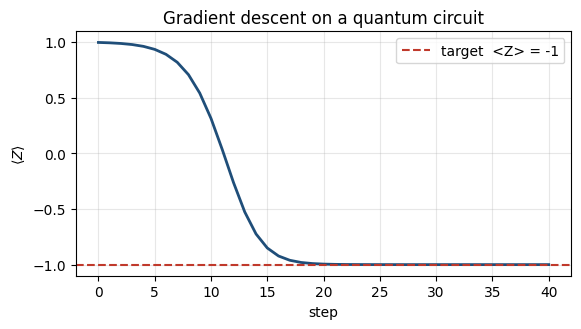

In [16]:
theta = pnp.array(0.1, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.3)   # θ ← θ - η∇L

history = [float(circuit(theta))]
for step in range(40):
    theta = opt.step(circuit, theta)               # 한 걸음 갱신
    history.append(float(circuit(theta)))

print("최종 θ =", round(float(theta), 4), " /  f(θ) =", round(history[-1], 4))

plt.figure(figsize=(6,3.4))
plt.plot(history, color="#1F4E79", lw=2)
plt.axhline(-1, ls="--", color="#C0392B", label="target  <Z> = -1")
plt.xlabel("step"); plt.ylabel(r"$\langle Z \rangle$")
plt.title("Gradient descent on a quantum circuit")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**코드 설명** — `qml.GradientDescentOptimizer`가 `θ ← θ − η∇L` 갱신을 자동으로 수행한다. 내부적으로 parameter-shift로 gradient를 구하므로, 고전 신경망과 똑같은 학습 루프로 양자 회로를 최적화할 수 있다.

## 0.7 푸리에 해석 기초 — 양자 모델의 표현력

Schuld 등(2021)은 angle encoding을 쓰는 양자 회로의 출력이 **입력에 대한 푸리에 급수**임을 보였다.
인코딩 게이트를 **L번 반복**하면 접근 가능한 주파수가 정확히 `[-L, L]`로 확장된다 — 회로 깊이가 곧 표현력이다.
PennyLane의 `qml.fourier`로 이를 학습 없이 직접 진단한다.

In [17]:
from pennylane.fourier import coefficients

def make_model(L):
    """인코딩(RX)을 L번 반복하는 1-큐비트 회로를 만든다"""
    dev = qml.device("default.qubit", wires=1)
    @qml.qnode(dev)
    def model(x):
        for _ in range(L):
            qml.RX(x, wires=0)     # 데이터 인코딩 (반복할수록 주파수 확장)
            qml.RY(0.7, wires=0)   # 고정 변분 게이트 (계수만 바꿈)
        return qml.expval(qml.PauliZ(0))
    return model

# 각 L에 대해 푸리에 계수를 구한다 (degree = L 까지)
for L in [1, 2, 3]:
    c = coefficients(make_model(L), 1, L)          # 복소 푸리에 계수
    freqs = np.fft.fftfreq(len(c), d=1/len(c))      # 대응하는 주파수 ω
    nz = sorted(int(f) for f, ci in zip(freqs, c) if np.abs(ci) > 1e-6)
    print(f"L={L}: 0이 아닌 주파수 ω = {nz}")

L=1: 0이 아닌 주파수 ω = [-1, 1]
L=2: 0이 아닌 주파수 ω = [-2, -1, 0, 1, 2]
L=3: 0이 아닌 주파수 ω = [-3, -2, -1, 0, 1, 2, 3]


**코드 설명** — `coefficients(f, n_inputs, degree)`가 회로 출력의 복소 푸리에 계수를 해석적으로 추출한다. 출력에서 보듯 **L이 커질수록 0이 아닌 주파수의 범위가 정확히 [−L, L]로 넓어진다**. 즉 회로 깊이가 표현 가능한 함수의 "주파수 대역폭"을 결정한다.

이를 스펙트럼 막대그래프로 시각화한다.

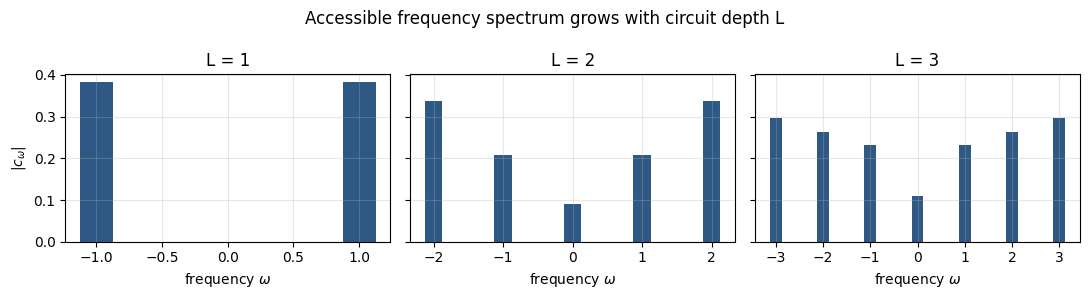

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, L in zip(axes, [1, 2, 3]):
    c = coefficients(make_model(L), 1, L)
    freqs = np.fft.fftfreq(len(c), d=1/len(c))
    order = np.argsort(freqs)
    ax.bar(freqs[order], np.abs(c)[order], width=0.25, color="#2E5984")
    ax.set_title(f"L = {L}")
    ax.set_xlabel(r"frequency $\omega$"); ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$|c_\omega|$")
fig.suptitle("Accessible frequency spectrum grows with circuit depth L")
plt.tight_layout(); plt.show()

**코드 설명** — 막대의 가로 범위가 L에 따라 ±1 → ±2 → ±3으로 넓어진다. 변분 파라미터는 이 막대의 "높이(계수)"만 조절할 뿐, 표현 가능한 주파수 집합 자체는 회로 구조가 정한다. 양자 모델 설계를 신호처리 관점으로 볼 수 있게 해 주는 결과다.

## 정리

| 절 | 핵심 코드 도구 | 확인한 사실 |
|----|----------------|-------------|
| 0.1 | `abs`, `np.exp`, `np.abs(ψ)**2` | 진폭은 복소수, 확률은 \|z\|² |
| 0.2 | `np.vdot`, `np.outer` | 내적=겹침, 외적=사영 연산자 |
| 0.3 | `scipy.linalg.expm` | 게이트는 유니터리, 회전은 매끄러움 |
| 0.4 | `np.linalg.eigh` | 측정=스펙트럼 분해, 기댓값=가중평균 |
| 0.5 | `np.kron`, 부분 대각합 | 2ⁿ 차원, 얽힘 엔트로피 |
| 0.6 | `qml.qnode`, `qml.grad` | parameter-shift = 정확한 미분 |
| 0.7 | `qml.fourier.coefficients` | 회로 깊이 = 주파수 = 표현력 |

이 노트북에서 다룬 선형대수·확률·미분·푸리에는 이후 Part 1의 첫 회로 실습과 Part 2의 변분 분류기·양자 커널·VQE로 그대로 이어진다.